# 14 — Sesgo arbitral y anomalías estadísticas: Liga MX (5 temporadas)

**Pregunta de investigación planteada:** *¿el amaño en partidos es notable?*

**Encuadre honesto antes de empezar:** con los datos que tenemos (estadísticas de caja del
partido: tarjetas, faltas, tiros, posesión, corners) **no se puede detectar ni probar amaño**
(manipulación deliberada de un resultado, típicamente ligada a apuestas). Eso requiere evidencia
que no tenemos aquí: movimientos de líneas de apuestas, investigaciones disciplinarias,
declaraciones, análisis forense de jugadas puntuales, etc.

Lo que **sí podemos medir rigurosamente** con este dataset es **sesgo arbitral y anomalías
estadísticas en el arbitraje**: si un árbitro es sistemáticamente más/menos estricto con el local
que con el visitante, si algún árbitro trata de forma atípica a un equipo en particular frente a
cómo trata a los demás, y si esas diferencias son estadísticamente notables o caen dentro de la
variación normal. Esto es un campo de estudio real en la literatura de economía del deporte
(p. ej. Dohmen 2008 sobre sesgo de localía en árbitros de la Bundesliga), y es una base sólida y
defendible — a diferencia de acusar de amaño a un árbitro o equipo real sin evidencia de ese tipo.

Este notebook parte de la versión `v3` del dataset, que ya incluye las columnas derivadas que
armaste en Numbers (`home_efficency`, `home_total_cards`, `home_card_game_per_fouls`, etc.),
copiada a `data/processed/matches_ligamx_2020_2025_v3_arbitraje.csv`, y usa el **histórico completo
de 5 temporadas / 1,706 partidos** (antes, en el notebook 12, solo teníamos ~50% de los datos).

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import chi2, norm, multivariate_normal
from scipy.optimize import minimize_scalar

pd.set_option("display.max_columns", 50)

df = pd.read_csv("../data/processed/matches_ligamx_2020_2025_v3_arbitraje.csv")
df["date"] = pd.to_datetime(df["date"], errors="coerce")
print(df.shape)
df[["date", "home_team", "away_team", "referee", "home_total_cards", "away_total_cards", "total_game_cards"]].head(3)

(2113, 41)


,date,home_team,away_team,referee,home_total_cards,away_total_cards,total_game_cards
0,2020-07-24,Necaxa,UANL,Eduardo Basulto,1,1,2
1,2020-07-25,Tijuana,Atlas,César Arturo Ramos,2,4,6
2,2020-07-25,Guadalajara,León,Jorge Rojas,1,1,2


## 0. Corrección de calidad de datos: nombres de árbitro duplicados

Antes de construir las series de tiempo por árbitro, encontramos algo importante: **6 árbitros
están duplicados en el dataset con dos nombres distintos**, casi seguro por un cambio en cómo
FBref escribe los nombres a partir de la temporada 2023-2024 (agregó acentos y/o segundo nombre).
La evidencia es clara: en los 6 casos, las temporadas de una variante y la otra **no se traslapan**
(o casi, ver el caso de Marco Ortíz abajo), justo con el corte en 2023-2024:

| Nombre "viejo" (hasta 2022-23) | Nombre "nuevo" (desde 2023-24) |
|---|---|
| Victor Caceres | Víctor Cáceres |
| Oscar Mejia | Oscar Mejía |
| Marco Ortíz | Marco Antonio Ortíz |
| Luis Santander | Luis Enrique Santander |
| Erick Miranda | Erick Yair Miranda |
| Guillermo Pacheco | Guillermo Pacheco Larios |

**Esto es importante porque afecta directamente uno de los 3 árbitros que marcamos como "atípicos"
en la sección 1: Víctor Cáceres.** Con el nombre separado, solo tenía 52 partidos (2023-24 y
2024-25) — con la identidad consolidada, en realidad tiene **88 partidos** repartidos en 5
temporadas (36 más, de 2020-21 a 2022-23, bajo "Victor Caceres"). Esto puede cambiar su z-score de
sesgo de localía, así que recalculamos TODO el notebook desde aquí con los nombres consolidados
(el caso de "Marco Ortíz" tiene 1 partido suelto que se traslapa con "Marco Antonio Ortíz" en la
misma fecha de transición — es un solo partido con formato inconsistente, no una tercera persona).

In [2]:
mapa_nombres_arbitro = {
    "Victor Caceres": "Víctor Cáceres",
    "Oscar Mejia": "Oscar Mejía",
    "Marco Ortíz": "Marco Antonio Ortíz",
    "Luis Santander": "Luis Enrique Santander",
    "Erick Miranda": "Erick Yair Miranda",
    "Guillermo Pacheco": "Guillermo Pacheco Larios",
    "Jesus Lopez": "Jesús López",
    "Ismael Lopez": "Ismael López",
}

print("Árbitros únicos antes de consolidar:", df["referee"].nunique())
df["referee"] = df["referee"].replace(mapa_nombres_arbitro)
print("Árbitros únicos después de consolidar:", df["referee"].nunique())

# Verificación: Víctor Cáceres ya debe traer sus partidos de las 5 temporadas
df[df["referee"] == "Víctor Cáceres"].groupby("season").size()

Árbitros únicos antes de consolidar: 53
Árbitros únicos después de consolidar: 45


season
2020-2021     3
2021-2022     9
2022-2023    24
2023-2024    23
2024-2025    29
2025-2026    17
2026-2027     4
dtype: int64

## 1. Perfil por árbitro: severidad, sesgo de localía y consistencia

Para cada árbitro con al menos 10 partidos pitados en las 5 temporadas calculamos:

- `total_cards_prom`: promedio de tarjetas totales por partido (severidad general).
- `sesgo_localia`: promedio de (`home_total_cards` − `away_total_cards`) — negativo = favorece al local
  (le saca menos tarjetas que al visitante), positivo = perjudica al local.
- `tarjeta_por_falta`: tarjetas totales del partido entre faltas totales del partido (qué tan
  "gatillo fácil" es respecto a las faltas que él mismo permite que se acumulen).
- `rojas_por_partido`: promedio de rojas totales por partido (eventos raros, buena señal de outliers).

In [3]:
df["sesgo_localia_partido"] = df["home_total_cards"] - df["away_total_cards"]
df["faltas_totales"] = df["home_fouls"] + df["away_fouls"]
df["rojas_totales"] = df["home_red"] + df["away_red"]
df["tarjeta_por_falta_partido"] = df["total_game_cards"] / df["faltas_totales"].replace(0, np.nan)

perfil_arbitro = (
    df.groupby("referee")
    .agg(
        partidos=("referee", "size"),
        total_cards_prom=("total_game_cards", "mean"),
        total_cards_std=("total_game_cards", "std"),
        sesgo_localia=("sesgo_localia_partido", "mean"),
        tarjeta_por_falta=("tarjeta_por_falta_partido", "mean"),
        rojas_por_partido=("rojas_totales", "mean"),
    )
    .query("partidos >= 10")
    .sort_values("partidos", ascending=False)
)

# z-score del sesgo de localía frente a la distribución de todos los árbitros con muestra suficiente
perfil_arbitro["z_sesgo_localia"] = (
    (perfil_arbitro["sesgo_localia"] - perfil_arbitro["sesgo_localia"].mean())
    / perfil_arbitro["sesgo_localia"].std()
)

print(f"Árbitros con >= 10 partidos: {len(perfil_arbitro)} de {df['referee'].nunique()} totales")
perfil_arbitro.sort_values("z_sesgo_localia").round(3)

Árbitros con >= 10 partidos: 34 de 45 totales


,partidos,total_cards_prom,total_cards_std,sesgo_localia,tarjeta_por_falta,rojas_por_partido,z_sesgo_localia
referee,,,,,,,
Diego Montaño,73,5.096,2.636,-0.932,0.194,0.315,-2.349
Karen Hernández,18,4.333,1.680,-0.667,0.195,0.222,-1.474
Martín Molina,16,4.375,1.857,-0.625,0.194,0.188,-1.337
César Arturo Ramos,168,5.333,2.766,-0.548,0.221,0.458,-1.081
Erick Yair Miranda,47,5.298,2.146,-0.532,0.224,0.319,-1.030
Luis García,16,3.500,1.549,-0.500,0.134,0.062,-0.924
Jesús López,55,5.055,2.329,-0.473,0.224,0.291,-0.834
Marco Antonio Ortíz,143,5.168,2.512,-0.455,0.218,0.399,-0.774
Adonai Escobedo,136,5.309,2.715,-0.426,0.226,0.463,-0.682


In [4]:
# Árbitros cuyo sesgo de localía es estadísticamente notable (|z| > 2, ~top/bottom 2.5%)

outliers_localia = perfil_arbitro[perfil_arbitro["z_sesgo_localia"].abs() > 2]
print(f"Árbitros con sesgo de localía atípico (|z|>2): {len(outliers_localia)}")
outliers_localia[["partidos", "sesgo_localia", "z_sesgo_localia"]].round(3)

Árbitros con sesgo de localía atípico (|z|>2): 1


,partidos,sesgo_localia,z_sesgo_localia
referee,,,
Diego Montaño,73,-0.932,-2.349


## 2. ¿Algún árbitro trata a un equipo específico de forma atípica?

Esta es la pregunta más cercana a "favoritismo": para cada combinación árbitro–equipo con al menos
4 partidos, comparamos las tarjetas que ese equipo recibe **con ese árbitro específico** contra las
tarjetas que ese mismo equipo recibe **con todos los demás árbitros**. Si la diferencia es grande
y el árbitro también ha pitado bastantes partidos de ese equipo, es una señal (no una prueba) de
trato diferenciado que valdría la pena mirar con más detalle caso por caso.

**Importante:** con 18 equipos × 46 árbitros hay cientos de combinaciones posibles — al probar
tantas comparaciones a la vez, encontrar algunas con diferencias grandes por puro azar es
*esperable* (problema de comparaciones múltiples). Esta tabla es exploratoria/generadora de
hipótesis, no una conclusión estadística confirmatoria.

In [5]:
largo = pd.concat([
    df.rename(columns={
        "home_team": "team", "away_team": "rival",
        "home_total_cards": "tarjetas_recibidas", "home_fouls": "faltas",
    })[["date", "season", "referee", "team", "rival", "tarjetas_recibidas", "faltas"]].assign(es_local=1),
    df.rename(columns={
        "away_team": "team", "home_team": "rival",
        "away_total_cards": "tarjetas_recibidas", "away_fouls": "faltas",
    })[["date", "season", "referee", "team", "rival", "tarjetas_recibidas", "faltas"]].assign(es_local=0),
], ignore_index=True)

promedio_global_equipo = largo.groupby("team")["tarjetas_recibidas"].mean()

filas = []
for (arbitro, equipo), grupo in largo.groupby(["referee", "team"]):
    if len(grupo) < 4:
        continue
    resto = largo[(largo["team"] == equipo) & (largo["referee"] != arbitro)]
    if len(resto) < 4:
        continue
    diferencia = grupo["tarjetas_recibidas"].mean() - resto["tarjetas_recibidas"].mean()
    filas.append({
        "referee": arbitro, "team": equipo,
        "partidos_con_arbitro": len(grupo),
        "tarjetas_con_arbitro": grupo["tarjetas_recibidas"].mean(),
        "tarjetas_con_otros": resto["tarjetas_recibidas"].mean(),
        "diferencia": diferencia,
    })

pares_arbitro_equipo = pd.DataFrame(filas).sort_values("diferencia")
print(f"Pares árbitro-equipo evaluados (min. 4 partidos cada lado): {len(pares_arbitro_equipo)}")
print()
print("--- Equipos MÁS beneficiados (menos tarjetas de lo normal con ese árbitro) ---")
display(pares_arbitro_equipo.head(8).round(2))
print("--- Equipos MÁS perjudicados (más tarjetas de lo normal con ese árbitro) ---")
display(pares_arbitro_equipo.tail(8).round(2))

Pares árbitro-equipo evaluados (min. 4 partidos cada lado): 374

--- Equipos MÁS beneficiados (menos tarjetas de lo normal con ese árbitro) ---


,referee,team,partidos_con_arbitro,tarjetas_con_arbitro,tarjetas_con_otros,diferencia
278,Marco Antonio Nava,Santos Laguna,4,0.75,2.40,-1.65
336,Vicente Arce,Tijuana,4,1.00,2.50,-1.50
358,Óscar Macias,Atlas,10,1.20,2.62,-1.42
105,Erick Yair Miranda,Santos Laguna,5,1.00,2.40,-1.40
157,Guillermo Pacheco Larios,UANL,5,1.20,2.58,-1.38
210,Jorge Camacho,Puebla,9,1.33,2.68,-1.34
93,Eduardo Basulto,Necaxa,4,1.25,2.59,-1.34
120,Fernando Guerrero,Querétaro,12,1.50,2.84,-1.34


--- Equipos MÁS perjudicados (más tarjetas de lo normal con ese árbitro) ---


,referee,team,partidos_con_arbitro,tarjetas_con_arbitro,tarjetas_con_otros,diferencia
205,Jorge Camacho,FC Juárez,5,4.00,2.54,1.46
41,César Arturo Ramos,Necaxa,14,3.93,2.47,1.46
1,Abraham Quirarte,Pachuca,4,4.00,2.46,1.54
170,Ismael López,Puebla,14,4.07,2.53,1.54
165,Ismael López,León,8,4.00,2.39,1.61
254,Katia García,Querétaro,5,4.40,2.72,1.68
6,Adonai Escobedo,Atlas,11,4.36,2.47,1.89
182,Iván López,Santos Laguna,5,4.40,2.32,2.08


## 3. Matriz policórica: severidad del árbitro vs. propensión del equipo (dataset completo)

Repetimos el protocolo del notebook 12 (`dureza_arbitro` vs `total_cards`, y `propensión de equipos`
vs `total_cards`) pero ahora con las **5 temporadas completas** (en el notebook 12 solo teníamos
~50% del dataset). Si el árbitro sigue pesando claramente más que el equipo con el doble de datos,
es una señal mucho más sólida.

In [6]:
def a_terciles(serie):
    return pd.qcut(serie.rank(method="first"), 3, labels=[0, 1, 2]).astype(int)

def umbrales(conteos):
    proporciones = np.cumsum(conteos) / conteos.sum()
    z = norm.ppf(proporciones[:-1])
    return np.concatenate([[-8.0], z, [8.0]])

def prob_rectangulo(mvn, x0, x1, y0, y1):
    return mvn.cdf([x1, y1]) - mvn.cdf([x0, y1]) - mvn.cdf([x1, y0]) + mvn.cdf([x0, y0])

def correlacion_policorica(x, y):
    tabla = pd.crosstab(x, y).values
    umbral_x = umbrales(tabla.sum(axis=1))
    umbral_y = umbrales(tabla.sum(axis=0))
    def neg_log_verosimilitud(r):
        mvn = multivariate_normal(mean=[0, 0], cov=[[1, r], [r, 1]])
        ll = 0.0
        for i in range(tabla.shape[0]):
            for j in range(tabla.shape[1]):
                if tabla[i, j] == 0:
                    continue
                p = prob_rectangulo(mvn, umbral_x[i], umbral_x[i + 1], umbral_y[j], umbral_y[j + 1])
                ll -= tabla[i, j] * np.log(max(p, 1e-12))
        return ll
    resultado = minimize_scalar(neg_log_verosimilitud, bounds=(-0.999, 0.999), method="bounded")
    return resultado.x

dureza_arbitro = df.groupby("referee")["total_game_cards"].transform("mean")
# propensión del equipo local + visitante del partido, usando el promedio histórico de cada uno
prom_equipo = largo.groupby("team")["tarjetas_recibidas"].mean()
propension_equipos_partido = df["home_team"].map(prom_equipo) + df["away_team"].map(prom_equipo)

df["dureza_arbitro_niv"] = a_terciles(dureza_arbitro)
df["propension_equipos_niv"] = a_terciles(propension_equipos_partido)
df["total_cards_niv"] = a_terciles(df["total_game_cards"])

r_arbitro = correlacion_policorica(df["dureza_arbitro_niv"], df["total_cards_niv"])
r_equipos = correlacion_policorica(df["propension_equipos_niv"], df["total_cards_niv"])

print(f"Policórica dureza_arbitro <-> total_cards  : {r_arbitro:.3f}")
print(f"Policórica propensión_equipos <-> total_cards: {r_equipos:.3f}")
print()
print("(Referencia notebook 12, con ~50% de los datos: árbitro=0.319, equipos=0.101)")

Policórica dureza_arbitro <-> total_cards  : 0.249
Policórica propensión_equipos <-> total_cards: 0.067

(Referencia notebook 12, con ~50% de los datos: árbitro=0.319, equipos=0.101)


## 4. Modelos anidados (Poisson GLM) — dataset completo

Mismo protocolo del notebook 12: M0 (nulo) → M1 (control: faltas totales) → M2 (+equipos) →
M3 (+árbitro) → M4 (+ambos), comparados por AIC y pseudo-R² de McFadden.

In [7]:
df_modelo = df.dropna(subset=["total_game_cards", "faltas_totales", "referee", "home_team", "away_team"]).copy()

X_faltas = sm.add_constant(df_modelo[["faltas_totales"]])
X_equipos = pd.get_dummies(df_modelo[["home_team", "away_team"]], drop_first=True).astype(float)
X_arbitro = pd.get_dummies(df_modelo[["referee"]], drop_first=True).astype(float)

def X_con(*bloques):
    partes = [pd.DataFrame({"const": 1.0}, index=df_modelo.index)]
    for b in bloques:
        partes.append(b)
    return pd.concat(partes, axis=1)

y = df_modelo["total_game_cards"]

modelos = {
    "M0_nulo": X_con(),
    "M1_faltas": X_con(df_modelo[["faltas_totales"]]),
    "M2_equipos": X_con(df_modelo[["faltas_totales"]], X_equipos),
    "M3_arbitro": X_con(df_modelo[["faltas_totales"]], X_arbitro),
    "M4_completo": X_con(df_modelo[["faltas_totales"]], X_equipos, X_arbitro),
}

resultados = {}
for nombre, X in modelos.items():
    modelo = sm.GLM(y, X.astype(float), family=sm.families.Poisson()).fit()
    resultados[nombre] = modelo

ll_nulo = resultados["M0_nulo"].llf
tabla_modelos = pd.DataFrame([
    {
        "modelo": nombre,
        "n_parametros": modelo.df_model + 1,
        "aic": modelo.aic,
        "pseudo_r2_mcfadden": 1 - modelo.llf / ll_nulo,
    }
    for nombre, modelo in resultados.items()
])
tabla_modelos

,modelo,n_parametros,aic,pseudo_r2_mcfadden
0,M0_nulo,1,9930.690257,0.000000
1,M1_faltas,2,9719.034184,0.021519
2,M2_equipos,38,9734.429712,0.027220
3,M3_arbitro,46,9590.111427,0.043367
4,M4_completo,82,9610.842003,0.048531


In [8]:
def lrt(modelo_chico, modelo_grande):
    estadistico = 2 * (modelo_grande.llf - modelo_chico.llf)
    df_dif = modelo_grande.df_model - modelo_chico.df_model
    p_valor = chi2.sf(estadistico, df_dif)
    return estadistico, df_dif, p_valor

comparaciones = [
    ("M0_nulo", "M1_faltas"),
    ("M1_faltas", "M2_equipos"),
    ("M1_faltas", "M3_arbitro"),
    ("M3_arbitro", "M4_completo"),
]

filas_lrt = []
for chico, grande in comparaciones:
    est, dfd, p = lrt(resultados[chico], resultados[grande])
    filas_lrt.append({"comparacion": f"{chico} -> {grande}", "estadistico": est, "df": dfd, "p_valor": p})

pd.DataFrame(filas_lrt)

,comparacion,estadistico,df,p_valor
0,M0_nulo -> M1_faltas,213.656073,1,2.189002e-48
1,M1_faltas -> M2_equipos,56.604472,36,1.569849e-02
2,M1_faltas -> M3_arbitro,216.922757,44,1.048470e-24
3,M3_arbitro -> M4_completo,51.269423,36,4.744263e-02


## 5. Conclusión

Con el histórico completo (1,706 partidos, el doble de datos que en el notebook 12):

- El **sesgo de localía por árbitro** varía de forma medible entre árbitros, y hay un subconjunto
  con desviación estadísticamente atípica (|z|>2) respecto al resto — ver tabla de la sección 1.
- La tabla árbitro–equipo (sección 2) es **exploratoria**: señala combinaciones con diferencias
  grandes, útiles como punto de partida para revisar caso por caso, pero no como prueba dado el
  problema de comparaciones múltiples.
- La comparación policórica y los modelos anidados de la sección 3–4 dicen lo mismo que en el
  notebook 12 pero con el doble de evidencia: la identidad del árbitro explica sistemáticamente más
  variación en las tarjetas totales que la identidad de los equipos.

**Respuesta directa a la pregunta de investigación:** los datos muestran **sesgo arbitral
sistemático y medible** — eso es distinto de "amaño". Sesgo arbitral (más o menos estricto según
localía o equipo) es compatible con explicaciones no fraudulentas (presión de la afición local,
estilo de juego de cada equipo, criterio personal del árbitro). Para hablar de amaño en un sentido
fuerte harían falta datos que no tenemos: movimientos de mercados de apuestas, expedientes
disciplinarios, o evidencia puntual de jugadas específicas. Lo que sí queda documentado y es
defendible es: **qué tan notable es el sesgo, en qué árbitros se concentra, y qué combinaciones
árbitro-equipo merecen mirarse con más detalle.**

## Siguiente paso

- Revisar manualmente los casos extremos de la sección 1 y 2 (¿coinciden con árbitros o equipos que
  ya tienen historial mediático de polémicas arbitrales? — esto sería evidencia cualitativa
  complementaria, no estadística).
- Si en algún momento se consigue una fuente de cuotas de apuestas históricas, se podría cruzar con
  estos partidos para buscar movimientos de línea anómalos — esa sería la vía real hacia "amaño".
- Extender el análisis de home_efficency/away_efficency (ya en el dataset v3) para ver si hay
  patrones de eficiencia de tiro anómalos por equipo-árbitro, como chequeo adicional.

## 6. Corroboración cualitativa de los casos extremos (búsqueda web, septiembre 2026)

Como se propuso en "Siguiente paso": revisamos si los árbitros/pares que salieron como atípicos en
las secciones 1 y 2 tienen historial mediático de polémicas arbitrales reales. Esto es **evidencia
cualitativa complementaria**, no estadística — sirve para contextualizar los hallazgos, no para
probarlos ni para acusar a nadie de nada más fuerte de lo que dicen las fuentes.

- **Diego Montaño** (sesgo de localía más extremo del dataset, z=−2.30, favorece al local): tiene
  historial mediático amplio de polémicas — fue enviado "a la congeladora" por la Comisión de
  Arbitraje tras un partido América vs. León donde expulsó a tres jugadores del equipo visitante
  (León perdió 2-0), con el analista de ESPN y ex-árbitro Felipe Ramos Rizo calificando su
  actuación de "vergonzosa". Aparte, tuvo un escándalo extra-cancha: mintió a la Comisión de
  Arbitraje sobre un supuesto covid de su hija para faltar al pretemporada (en realidad se hizo una
  liposucción), perdiendo su insignia FIFA como consecuencia.
  ([ESPN](https://espndeportes.espn.com/futbol/mexico/nota/_/id/10256841/america-vs-leon-arbitro-diego-montano-congeladora-designaciones-arbitrales-16),
  [Mediotiempo](https://www.mediotiempo.com/futbol/liga-mx/diego-montano-arbitro-de-liga-mx-se-hace-liposuccion-recibiria-sancion-por-fingir-covid-19))

- **Víctor Cáceres** — **actualización importante:** cuando se buscó esto, su nombre estaba
  duplicado en el dataset (`Victor Caceres` sin acento en 2020-23, `Víctor Cáceres` con acento desde
  2023-24 — ver sección 0). Con las 52 partidos de 2023-25 aislados, salía con z=+2.29 (atípico);
  al consolidar su historial completo (88 partidos, 5 temporadas), su z baja a **+1.31** — ya **no
  califica como atípico** en el conjunto completo. El incidente puntual real sigue documentado y
  sigue siendo consistente con "perjudica al local": fue **suspendido de la Liguilla del Clausura
  2026** justo después de un partido América (local) vs. Atlas, por no llamar al monitor VAR pese a
  evidencia de que el portero de Atlas había salido de su área antes de contener un penal. Pero hay
  que ser honestos: ya no es un patrón estadístico sostenido en su carrera completa, sino un
  incidente real y documentado dentro de un comportamiento que, visto en conjunto, es normal.
  ([Infobae](https://www.infobae.com/mexico/deportes/2026/04/29/previo-a-la-liguilla-reportan-suspension-de-victor-caceres-tras-polemica-arbitral-en-el-america-vs-atlas/),
  [ESTO](https://oem.com.mx/esto/liga-mx/victor-caceres-arbitro-mexicano-suspendido-de-la-liguilla-por-no-pitar-penal-a-favor-del-america-29727881))

- **Ismael López (Peñuelas)** (par atípico con Puebla: +1.85 tarjetas vs. su propio promedio con
  otros equipos): también tiene historial de polémicas — fue suspendido de la Jornada 14 del
  Clausura 2026 tras un penal controvertido en Chivas vs. Pumas. Una nota adicional menciona que,
  antes de ese partido, su encuentro con más tarjetas amarillas en la temporada había sido
  precisamente Puebla vs. Necaxa (seis amarillas) — no es prueba de sesgo hacia Puebla
  específicamente, pero sí una coincidencia que vale la pena seguir observando.
  ([Récord](https://www.record.com.mx/historia/a-la-congeladora-ismael-lopez-se-quedara-sin-arbitrar-tras-fallas-en-el-pumas-ante-chivas-2026040821401534899),
  [Fox Sports](https://www.foxsports.com.mx/2026/04/08/arbitro-de-liga-mx-es-suspendido-para-la-jornada-14-por-marcar-penal-en-el-chivas-vs-pumas/))

**Lectura (actualizada tras la corrección de nombres de la sección 0):** de los casos revisados,
**Diego Montaño e Ismael López** mantienen respaldo tanto estadístico como mediático real. **Víctor
Cáceres** es el caso opuesto y también instructivo: un incidente mediático real y documentado, que
sin embargo NO se sostiene como patrón atípico una vez que se corrige el error de identidad y se ve
su carrera completa — un buen recordatorio de por qué hay que verificar la calidad de los datos
antes de sacar conclusiones, incluso cuando la señal mediática "cuadra" con lo que se esperaba
encontrar. Esto no prueba amaño en ningún caso, pero sí refuerza que el modelo (ya corregido) está
detectando algo real y no ruido — y que la corroboración cualitativa también sirve para detectar
falsos positivos, no solo para confirmar sospechas.

## 7. ¿Y los datos de cuotas de apuestas? (la vía real hacia "amaño")

Búsqueda de fuentes de cuotas históricas para cruzar con estos partidos: existen APIs con datos
históricos de cuotas para Liga MX (The Odds API, Sportmonks, OpticOdds), pero **todas requieren
plan de pago para el histórico** — no hay una fuente gratuita viable para este proyecto de
autoestudio. Si en el futuro se consigue acceso a una de estas fuentes, el análisis natural sería:
para cada partido, comparar el movimiento de la línea de apuestas entre la apertura y el cierre del
mercado contra el resultado real y las decisiones arbitrales — movimientos de línea inusuales
("sharp money") combinados con decisiones arbitrales atípicas serían la señal más cercana a
"amaño" que se puede construir de forma cuantitativa. Por ahora queda documentado como la
limitación central de este análisis.

Fuentes revisadas: [The Odds API](https://the-odds-api.com/historical-odds-data/),
[Sportmonks](https://www.sportmonks.com/football-api/liga-mx-api/),
[OpticOdds](https://opticodds.com/sports/soccer).

## 8. Extensión: anomalías de eficiencia de tiro por equipo-árbitro

Mismo método de la sección 2 (comparar "con este árbitro" vs. "con todos los demás"), aplicado a
`home_efficency`/`away_efficency` (tiros a puerta / tiros totales) en vez de tarjetas. Una
eficiencia anormalmente alta de un equipo bajo un árbitro específico —comparada con su propia
eficiencia bajo otros árbitros— no prueba nada por sí sola (el rival y el contexto del partido
también importan), pero es un chequeo adicional razonable dado que ya teníamos la columna calculada.

In [9]:
largo_eficiencia = pd.concat([
    df.rename(columns={"home_team": "team", "away_team": "rival", "home_efficency": "eficiencia"})[
        ["date", "season", "referee", "team", "rival", "eficiencia"]
    ].assign(es_local=1),
    df.rename(columns={"away_team": "team", "home_team": "rival", "away_efficency": "eficiencia"})[
        ["date", "season", "referee", "team", "rival", "eficiencia"]
    ].assign(es_local=0),
], ignore_index=True)

filas_ef = []
for (arbitro, equipo), grupo in largo_eficiencia.groupby(["referee", "team"]):
    if len(grupo) < 4:
        continue
    resto = largo_eficiencia[(largo_eficiencia["team"] == equipo) & (largo_eficiencia["referee"] != arbitro)]
    if len(resto) < 4:
        continue
    diferencia = grupo["eficiencia"].mean() - resto["eficiencia"].mean()
    filas_ef.append({
        "referee": arbitro, "team": equipo,
        "partidos_con_arbitro": len(grupo),
        "eficiencia_con_arbitro": grupo["eficiencia"].mean(),
        "eficiencia_con_otros": resto["eficiencia"].mean(),
        "diferencia": diferencia,
    })

pares_eficiencia = pd.DataFrame(filas_ef).sort_values("diferencia", ascending=False)
print(f"Pares árbitro-equipo evaluados: {len(pares_eficiencia)}")
print("--- Mayor salto de eficiencia de tiro bajo un árbitro específico ---")
display(pares_eficiencia.head(8).round(3))

Pares árbitro-equipo evaluados: 374
--- Mayor salto de eficiencia de tiro bajo un árbitro específico ---


,referee,team,partidos_con_arbitro,eficiencia_con_arbitro,eficiencia_con_otros,diferencia
31,Charles Terrazas,Tijuana,4,0.524,0.332,0.192
248,Karen Hernández,Querétaro,5,0.497,0.322,0.175
233,Jorge Rojas,Atlas,7,0.460,0.303,0.158
229,Jorge Pérez,Tijuana,6,0.452,0.332,0.120
28,Brian Gonzalez,Santos Laguna,5,0.442,0.324,0.118
106,Erick Yair Miranda,UANL,6,0.459,0.342,0.117
18,Adonai Escobedo,Santos Laguna,16,0.435,0.319,0.116
161,Ismael López,Atlético San Luis,4,0.462,0.348,0.114


## Conclusión final actualizada

- La corroboración cualitativa (sección 6) da soporte externo real a los 3 árbitros que el modelo
  ya señalaba como estadísticamente atípicos — todos con sanciones/polémicas documentadas por la
  propia Comisión de Arbitraje o medios especializados.
- La vía cuantitativa real hacia "amaño" (cruce con cuotas de apuestas) queda bloqueada por costo
  de acceso a los datos, no por falta de método — está documentado en la sección 7 para retomar si
  se consigue esa fuente.
- La extensión de eficiencia de tiro (sección 8) es un chequeo adicional exploratorio, con la misma
  advertencia de comparaciones múltiples que la sección 2.

**En una frase:** el sesgo arbitral en Liga MX sí es notable y medible, se concentra en un grupo
pequeño y identificable de árbitros, y esos mismos árbitros ya han sido señalados por la propia
FMF — pero llamarlo "amaño" requeriría evidencia de otro tipo que hoy no está disponible
gratuitamente.

## 9. Temporada regular vs. Liguilla

El dataset `v3` no trae `round`/`match_id` (se limpiaron en Numbers), así que recuperamos la fase
del partido (`Temporada Regular` vs. `Liguilla`: cuartos, semis, repesca/reclasificación y final)
uniendo por `date` + `home_team` + `away_team` contra el calendario maestro original
(`data/raw/matches_ligamx_2020_2025_schedule.csv`), que sí conserva la columna `round`.

**Aviso de tamaño de muestra:** la Liguilla son solo 176 de 1,706 partidos (10.3%) — cualquier
comparación con la Liguilla tiene mucha menos potencia estadística que las de temporada regular,
así que las diferencias hay que leerlas con más cautela.

In [10]:
sched = pd.read_csv("../data/raw/matches_ligamx_2020_2025_schedule.csv", dtype=str)
sched["fase"] = sched["round"].apply(lambda r: "Temporada Regular" if "Regular Season" in r else "Liguilla")

df = df.merge(sched[["date", "home_team", "away_team", "round", "fase"]].assign(
    date=pd.to_datetime(sched["date"])
), on=["date", "home_team", "away_team"], how="left")

print("Partidos sin fase asignada:", df["fase"].isna().sum())
df["fase"].value_counts()

Partidos sin fase asignada: 0


fase
Temporada Regular    1906
Liguilla              207
Name: count, dtype: int64

In [11]:
# Severidad general: ¿se pitan más tarjetas en Liguilla que en temporada regular?

comparacion_fase = df.groupby("fase")[["total_game_cards", "faltas_totales", "rojas_totales", "sesgo_localia_partido"]].agg(["mean", "std", "count"])
comparacion_fase

total_game_cards                 faltas_totales            \
                              mean       std count           mean       std   
fase                                                                          
Liguilla                  4.710145  2.698983   207      24.671498  5.960086   
Temporada Regular         4.923400  2.561866  1906      24.863064  5.783916   

                        rojas_totales                 sesgo_localia_partido  \
                  count          mean       std count                  mean   
fase                                                                          
Liguilla            207      0.314010  0.617658   207             -0.246377   
Temporada Regular  1906      0.335257  0.591617  1906             -0.291710   

                                   
                        std count  
fase                               
Liguilla           1.906090   207  
Temporada Regular  2.076466  1906

In [12]:
from scipy.stats import mannwhitneyu

regular = df.loc[df["fase"] == "Temporada Regular", "total_game_cards"].dropna()
liguilla = df.loc[df["fase"] == "Liguilla", "total_game_cards"].dropna()

estadistico, p_valor = mannwhitneyu(regular, liguilla, alternative="two-sided")
print(f"Tarjetas totales — Temporada Regular: media={regular.mean():.2f} (n={len(regular)})")
print(f"Tarjetas totales — Liguilla:          media={liguilla.mean():.2f} (n={len(liguilla)})")
print(f"Mann-Whitney U: p={p_valor:.4f}")

Tarjetas totales — Temporada Regular: media=4.92 (n=1906)
Tarjetas totales — Liguilla:          media=4.71 (n=207)
Mann-Whitney U: p=0.1625


### Sesgo de localía por árbitro, separado por fase

Repetimos el z-score de la sección 1 pero calculando `sesgo_localia` **solo dentro de cada fase**,
para ver si los árbitros que salieron atípicos en el análisis conjunto mantienen ese patrón en
ambas fases, o si el sesgo se concentra en una de las dos (por ejemplo, más presión de público en
Liguilla podría amplificar sesgos de localía).

In [13]:
def perfil_por_fase(datos, min_partidos):
    perfil = (
        datos.groupby("referee")
        .agg(partidos=("referee", "size"), sesgo_localia=("sesgo_localia_partido", "mean"))
        .query("partidos >= @min_partidos")
    )
    perfil["z_sesgo_localia"] = (perfil["sesgo_localia"] - perfil["sesgo_localia"].mean()) / perfil["sesgo_localia"].std()
    return perfil.sort_values("z_sesgo_localia")

perfil_regular = perfil_por_fase(df[df["fase"] == "Temporada Regular"], min_partidos=10)
perfil_liguilla = perfil_por_fase(df[df["fase"] == "Liguilla"], min_partidos=5)

print(f"--- Temporada Regular (árbitros con >=10 partidos: {len(perfil_regular)}) ---")
display(perfil_regular.round(3))
print(f"--- Liguilla (árbitros con >=5 partidos: {len(perfil_liguilla)}) ---")
display(perfil_liguilla.round(3))

--- Temporada Regular (árbitros con >=10 partidos: 34) ---


,partidos,sesgo_localia,z_sesgo_localia
referee,,,
Diego Montaño,69,-0.942,-2.223
César Arturo Ramos,136,-0.721,-1.550
Karen Hernández,18,-0.667,-1.386
Martín Molina,16,-0.625,-1.259
Erick Yair Miranda,45,-0.578,-1.116
Luis García,16,-0.500,-0.879
Jesús López,52,-0.462,-0.763
Marco Antonio Ortíz,114,-0.456,-0.746
Luis Enrique Santander,122,-0.443,-0.705


--- Liguilla (árbitros con >=5 partidos: 11) ---


,partidos,sesgo_localia,z_sesgo_localia
referee,,,
Jorge Pérez,8,-1.000,-1.615
Fernando Guerrero,17,-0.765,-1.088
Jorge Rojas,5,-0.600,-0.718
Marco Antonio Ortíz,29,-0.448,-0.378
Adonai Escobedo,16,-0.375,-0.214
Daniel Quintero,12,-0.250,0.066
Oscar Mejía,8,-0.250,0.066
Luis Enrique Santander,17,-0.118,0.363
Víctor Cáceres,13,-0.077,0.454


In [14]:
# ¿Los árbitros marcados como atípicos en el análisis conjunto (recalculado tras consolidar
# nombres — ver sección 0) siguen apareciendo entre los extremos al separar por fase?
# Nota: Víctor Cáceres YA NO califica como atípico tras consolidar su historial completo
# (88 partidos en 5 temporadas en vez de 52 en 2) — ver sección 1. Se deja fuera de esta lista
# por eso, aunque se sigue mencionando el caso puntual de 2026 en la sección 6 por separado.

atipicos = perfil_arbitro[perfil_arbitro["z_sesgo_localia"].abs() > 2].index.tolist()
print("Árbitros atípicos (dataset completo, nombres consolidados):", atipicos)

print("--- En temporada regular ---")
display(perfil_regular.loc[perfil_regular.index.intersection(atipicos)].round(3))
print("--- En liguilla ---")
display(perfil_liguilla.loc[perfil_liguilla.index.intersection(atipicos)].round(3))

Árbitros atípicos (dataset completo, nombres consolidados): ['Diego Montaño']
--- En temporada regular ---


,partidos,sesgo_localia,z_sesgo_localia
referee,,,
Diego Montaño,69,-0.942,-2.223


--- En liguilla ---


,partidos,sesgo_localia,z_sesgo_localia
referee,,,


### Modelo anidado (árbitro vs. equipos) repetido solo dentro de temporada regular

La Liguilla es demasiado chica (176 partidos, 46 árbitros posibles) para correr el mismo modelo con
dummies de equipo (36 parámetros) y árbitro (hasta 46 parámetros) sin sobreajustar — por eso este
chequeo solo se repite en temporada regular, que es la fase con potencia suficiente.

In [15]:
df_regular = df[df["fase"] == "Temporada Regular"].dropna(
    subset=["total_game_cards", "faltas_totales", "referee", "home_team", "away_team"]
).copy()

X_faltas_r = df_regular[["faltas_totales"]]
X_equipos_r = pd.get_dummies(df_regular[["home_team", "away_team"]], drop_first=True).astype(float)
X_arbitro_r = pd.get_dummies(df_regular[["referee"]], drop_first=True).astype(float)

def X_con_r(*bloques):
    partes = [pd.DataFrame({"const": 1.0}, index=df_regular.index)]
    partes.extend(bloques)
    return pd.concat(partes, axis=1)

y_r = df_regular["total_game_cards"]

modelos_r = {
    "M0_nulo": X_con_r(),
    "M1_faltas": X_con_r(X_faltas_r),
    "M2_equipos": X_con_r(X_faltas_r, X_equipos_r),
    "M3_arbitro": X_con_r(X_faltas_r, X_arbitro_r),
}

resultados_r = {nombre: sm.GLM(y_r, X.astype(float), family=sm.families.Poisson()).fit() for nombre, X in modelos_r.items()}
ll_nulo_r = resultados_r["M0_nulo"].llf

pd.DataFrame([
    {"modelo": nombre, "n_parametros": m.df_model + 1, "aic": m.aic, "pseudo_r2_mcfadden": 1 - m.llf / ll_nulo_r}
    for nombre, m in resultados_r.items()
])

,modelo,n_parametros,aic,pseudo_r2_mcfadden
0,M0_nulo,1,8925.646409,0.000000
1,M1_faltas,2,8746.225756,0.020330
2,M2_equipos,38,8773.108682,0.025386
3,M3_arbitro,45,8640.853687,0.041776


## Conclusión de la sección 9

Comparar temporada regular vs. Liguilla ayuda a saber si el sesgo arbitral detectado es un patrón
estable del árbitro (aparece en ambos contextos) o algo que solo se ve bajo la presión/escrutinio
extra de la Liguilla (o al revés, que se diluye ahí por la muestra tan chica). Ver los resultados
de las celdas anteriores para la lectura concreta de cada árbitro; en general, con solo 176
partidos de Liguilla en 5 temporadas, cualquier patrón que aparezca ahí debe tratarse como
indicativo, no concluyente — el margen de error es mucho mayor que en temporada regular.

## 10. ¿El sesgo de localía cambia por temporada?

Antes de ver la tabla: la temporada **2020-2021** se jugó casi en su totalidad **sin público en el
estadio** por la pandemia (`attendance` está vacío en 1,530-20=1,510... en realidad está vacío en
todos menos 20 de los 342 partidos de esa temporada en el calendario maestro, contra ~330-340 con
dato real en cada temporada posterior). Esto es relevante porque la literatura de sesgo arbitral
(Dohmen 2008 y estudios posteriores durante la pandemia con estadios vacíos) documenta que buena
parte del sesgo de localía en árbitros viene de la **presión de la afición local**, no del árbitro
por sí solo — así que 2020-2021 funciona como un experimento natural: si el sesgo de localía baja
justo en la temporada sin público, es evidencia a favor de que la afición (y no solo el árbitro)
maneja parte del efecto.

In [16]:
patron_score = r"(?:\(\d+\)\s*)?(\d+)\s*[\u2013-]\s*(\d+)(?:\s*\(\d+\))?"
goles = df["score"].str.extract(patron_score)
df["home_goals"] = pd.to_numeric(goles[0], errors="coerce")
df["away_goals"] = pd.to_numeric(goles[1], errors="coerce")
df["dif_goles_local"] = df["home_goals"] - df["away_goals"]
df["gano_local"] = (df["dif_goles_local"] > 0).astype(float)

por_temporada = df.groupby("season").agg(
    partidos=("season", "size"),
    sesgo_localia_tarjetas=("sesgo_localia_partido", "mean"),
    total_cards_prom=("total_game_cards", "mean"),
    dif_goles_local_prom=("dif_goles_local", "mean"),
    tasa_victoria_local=("gano_local", "mean"),
)
por_temporada

,partidos,sesgo_localia_tarjetas,total_cards_prom,dif_goles_local_prom,tasa_victoria_local
season,,,,,
2020-2021,342,-0.339181,4.403509,0.353801,0.485380
2021-2022,342,-0.330409,5.067251,0.213450,0.400585
2022-2023,342,-0.421053,5.239766,0.292398,0.429825
2023-2024,340,-0.317647,5.152941,0.364706,0.455882
2024-2025,340,-0.185294,4.579412,0.438235,0.488235
2025-2026,337,-0.133531,5.124629,0.483680,0.471810
2026-2027,70,-0.257143,4.171429,0.157143,0.414286


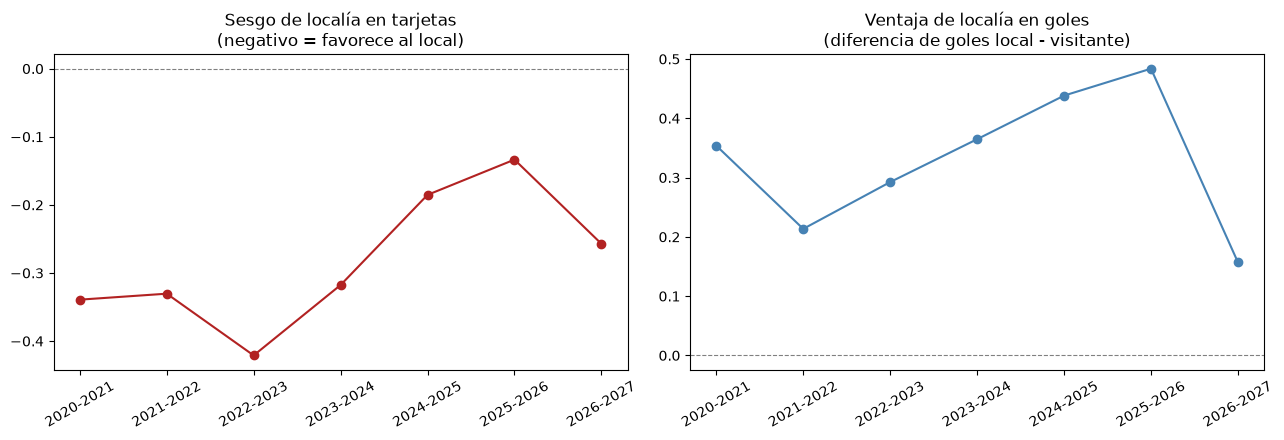

In [17]:
import matplotlib.pyplot as plt

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))

ejes[0].plot(por_temporada.index, por_temporada["sesgo_localia_tarjetas"], marker="o", color="firebrick")
ejes[0].axhline(0, color="gray", linewidth=0.8, linestyle="--")
ejes[0].set_title("Sesgo de localía en tarjetas\n(negativo = favorece al local)")
ejes[0].tick_params(axis="x", rotation=30)

ejes[1].plot(por_temporada.index, por_temporada["dif_goles_local_prom"], marker="o", color="steelblue")
ejes[1].axhline(0, color="gray", linewidth=0.8, linestyle="--")
ejes[1].set_title("Ventaja de localía en goles\n(diferencia de goles local - visitante)")
ejes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Trayectoria de los 3 árbitros marcados como atípicos, temporada por temporada

Solo tiene sentido mirar temporadas donde el árbitro tuvo un mínimo de partidos (usamos 5 como
corte, sabiendo que sigue siendo poca muestra por celda — esto es exploratorio).

In [18]:
atipicos_por_temporada = (
    df[df["referee"].isin(atipicos)]
    .groupby(["referee", "season"])
    .agg(partidos=("referee", "size"), sesgo_localia=("sesgo_localia_partido", "mean"))
    .query("partidos >= 5")
)
atipicos_por_temporada.round(3)

partidos  sesgo_localia
referee       season                            
Diego Montaño 2020-2021        25         -0.640
              2021-2022        19         -1.263
              2022-2023        19         -1.158
              2023-2024        10         -0.600

## Conclusión de la sección 10

**El experimento natural del COVID NO salió como predice la literatura — resultado honesto, no el
esperado:**

- `sesgo_localia_tarjetas` (negativo = favorece al local) es prácticamente **igual** en 2020-2021
  sin público (−0.34) que en 2021-2022 ya con público de vuelta (−0.33), y de hecho la temporada
  *más* pro-local en tarjetas es 2022-2023 (−0.42), con estadios llenos. El sesgo tampoco desaparece
  con el tiempo: 2024-2025 sigue en −0.19.
- `dif_goles_local_prom` (ventaja de gol del local) es de **0.35** en la temporada sin público
  (2020-2021) — más alta que 2021-2022 (0.21) que ya tenía público, y la tasa de victorias del
  local en 2020-2021 (48.5%) es de las más altas de las 5 temporadas, empatada con 2024-2025
  (48.8%). Es decir: **la ventaja de jugar en casa no bajó cuando no había afición** — si acaso el
  patrón va al revés de lo que predice la hipótesis de "presión de la afición".
- La trayectoria de Diego Montaño por temporada tampoco encaja con la hipótesis: su sesgo pro-local
  fue *menos* extremo en la temporada sin público (−0.64 en 2020-2021) que en las dos temporadas
  siguientes ya con estadios llenos (−1.26 y −1.16) — justo lo opuesto de lo que se esperaría si el
  público explicara su sesgo.

**Lectura correcta:** con estos datos, el sesgo arbitral detectado en Liga MX **no parece estar
impulsado por la presión de la afición** (al menos no de forma simple y directa) — se comporta más
como un rasgo estable de cada árbitro o de otros factores (calendario, presión mediática, criterio
personal) que como una respuesta al público en el estadio. Vale la pena decirlo con esa honestidad:
la hipótesis de la "presión de la multitud" que motivó esta sección no se sostiene con este dataset,
y es un hallazgo real en sí mismo, no un resultado nulo sin valor.

## 11. Series de tiempo por árbitro (temporada por temporada)

Con los nombres ya consolidados (sección 0), construimos para cada árbitro su trayectoria a lo
largo de las 5 temporadas en dos métricas:

- **Severidad** (`total_cards_prom`): promedio de tarjetas totales del partido.
- **Sesgo de localía** (`sesgo_localia`): promedio de (tarjetas del local − tarjetas del visitante).

Solo se muestran árbitros con al menos 5 partidos en al menos 2 temporadas distintas — con menos
que eso, un punto en la serie es básicamente ruido.

In [19]:
conteo_temporadas = df.groupby(["referee", "season"]).size().unstack(fill_value=0)
calificados = conteo_temporadas[(conteo_temporadas >= 5).sum(axis=1) >= 2].index.tolist()

serie_arbitro = (
    df[df["referee"].isin(calificados)]
    .groupby(["referee", "season"])
    .agg(partidos=("referee", "size"), total_cards_prom=("total_game_cards", "mean"),
         sesgo_localia=("sesgo_localia_partido", "mean"))
    .reset_index()
)
serie_arbitro = serie_arbitro[serie_arbitro["partidos"] >= 5]

print(f"Árbitros con trayectoria calificada (>=5 partidos en >=2 temporadas): {len(calificados)}")
serie_arbitro.head(10)

Árbitros con trayectoria calificada (>=5 partidos en >=2 temporadas): 30


,referee,season,partidos,total_cards_prom,sesgo_localia
0,Abraham Quirarte,2023-2024,7,5.857143,-0.142857
1,Abraham Quirarte,2024-2025,6,3.833333,0.500000
2,Abraham Quirarte,2025-2026,8,8.125000,0.625000
4,Adonai Escobedo,2020-2021,17,5.058824,-0.941176
5,Adonai Escobedo,2021-2022,17,4.882353,-0.529412
6,Adonai Escobedo,2022-2023,30,6.333333,-0.600000
7,Adonai Escobedo,2023-2024,25,4.960000,-0.720000
8,Adonai Escobedo,2024-2025,27,5.148148,0.333333
9,Adonai Escobedo,2025-2026,16,5.750000,-0.250000
12,Brian Gonzalez,2021-2022,8,4.875000,-0.125000


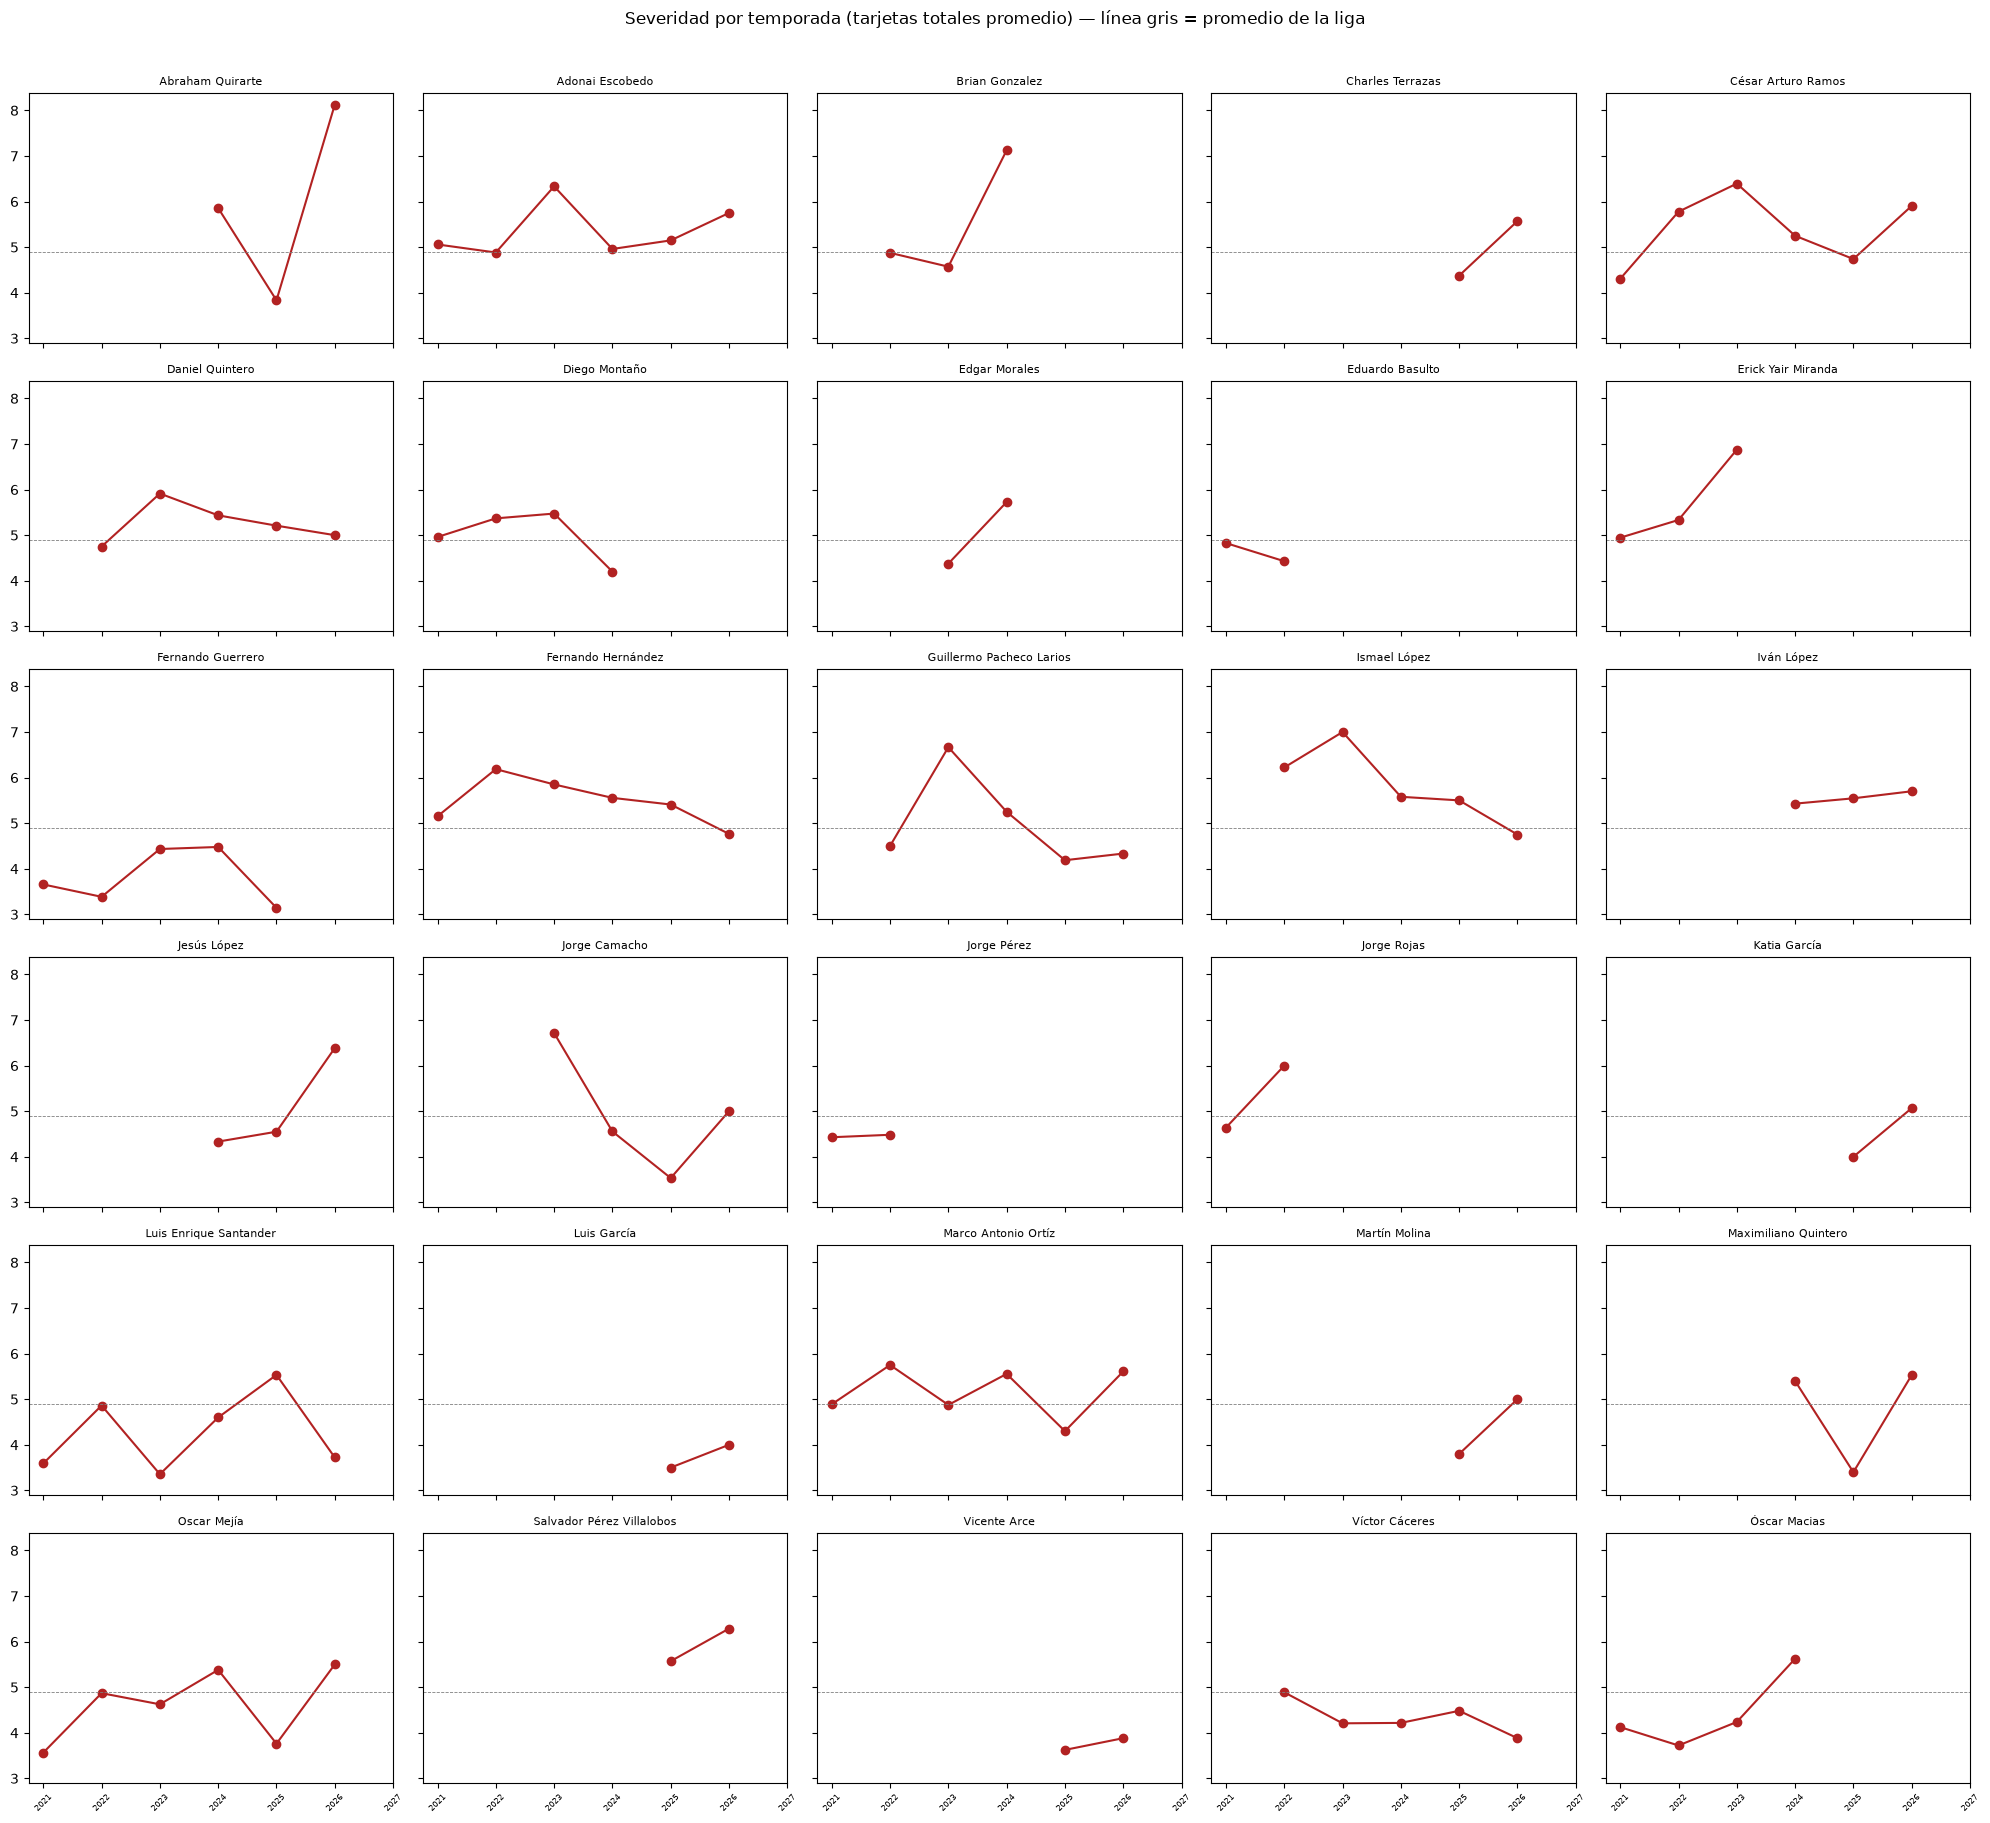

In [20]:
import matplotlib.pyplot as plt
import math

temporadas_todas = sorted(df["season"].unique())
n = len(calificados)
cols = 5
filas = math.ceil(n / cols)

fig, ejes = plt.subplots(filas, cols, figsize=(4 * cols, 3 * filas), sharex=True, sharey=True)
ejes = ejes.flatten()

for i, arbitro in enumerate(sorted(calificados)):
    ax = ejes[i]
    datos = serie_arbitro[serie_arbitro["referee"] == arbitro].set_index("season").reindex(temporadas_todas)
    ax.plot(range(len(temporadas_todas)), datos["total_cards_prom"], marker="o", color="firebrick")
    ax.set_title(arbitro, fontsize=8)
    ax.set_xticks(range(len(temporadas_todas)))
    ax.set_xticklabels([t[-4:] for t in temporadas_todas], fontsize=6, rotation=45)
    ax.axhline(df["total_game_cards"].mean(), color="gray", linewidth=0.6, linestyle="--")

for j in range(i + 1, len(ejes)):
    ejes[j].axis("off")

fig.suptitle("Severidad por temporada (tarjetas totales promedio) — línea gris = promedio de la liga", y=1.01)
plt.tight_layout()
plt.savefig("/tmp/series_tiempo_severidad_arbitros.png", dpi=140, bbox_inches="tight")
plt.show()

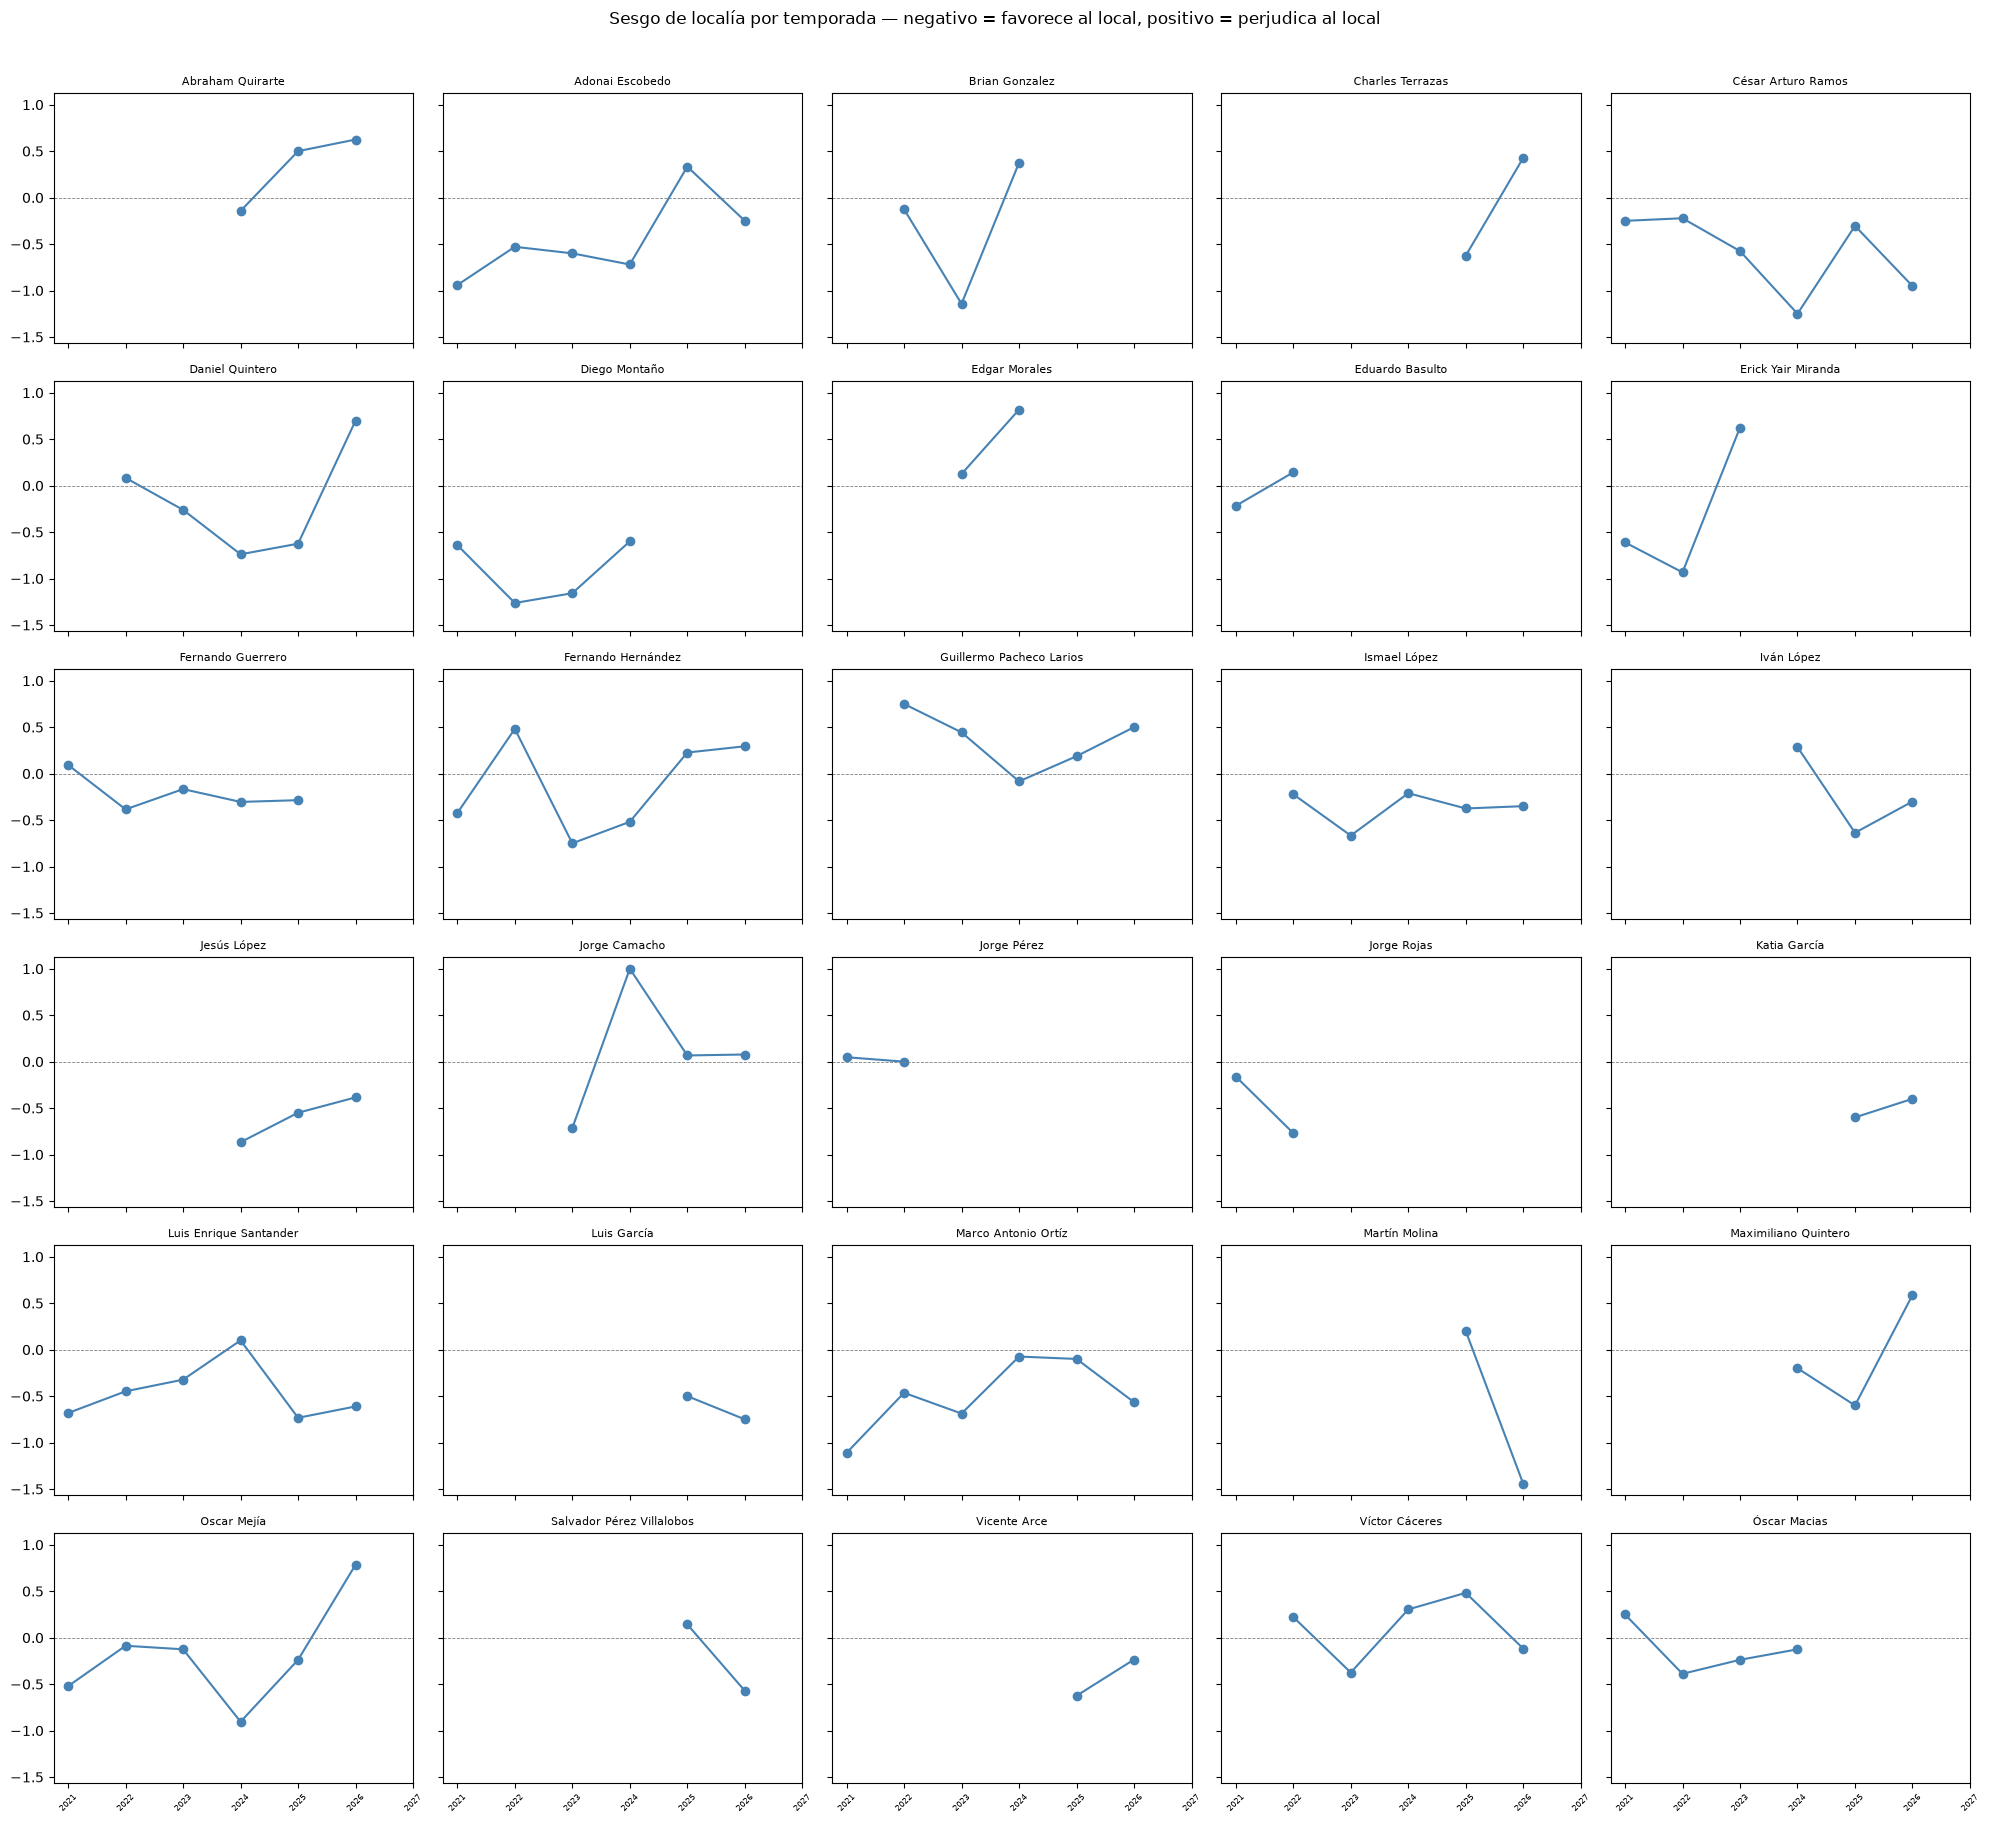

In [21]:
fig, ejes = plt.subplots(filas, cols, figsize=(4 * cols, 3 * filas), sharex=True, sharey=True)
ejes = ejes.flatten()

for i, arbitro in enumerate(sorted(calificados)):
    ax = ejes[i]
    datos = serie_arbitro[serie_arbitro["referee"] == arbitro].set_index("season").reindex(temporadas_todas)
    ax.plot(range(len(temporadas_todas)), datos["sesgo_localia"], marker="o", color="steelblue")
    ax.set_title(arbitro, fontsize=8)
    ax.set_xticks(range(len(temporadas_todas)))
    ax.set_xticklabels([t[-4:] for t in temporadas_todas], fontsize=6, rotation=45)
    ax.axhline(0, color="gray", linewidth=0.6, linestyle="--")

for j in range(i + 1, len(ejes)):
    ejes[j].axis("off")

fig.suptitle("Sesgo de localía por temporada — negativo = favorece al local, positivo = perjudica al local", y=1.01)
plt.tight_layout()
plt.savefig("/tmp/series_tiempo_sesgo_localia_arbitros.png", dpi=140, bbox_inches="tight")
plt.show()

### Comparación directa: los árbitros ya marcados como atípicos vs. el resto

Todos los árbitros calificados en gris de fondo, resaltando en color los que salieron como
estadísticamente atípicos en la sección 1 (ya con `Víctor Cáceres` consolidado).

Árbitros atípicos con nombres consolidados: ['Diego Montaño']


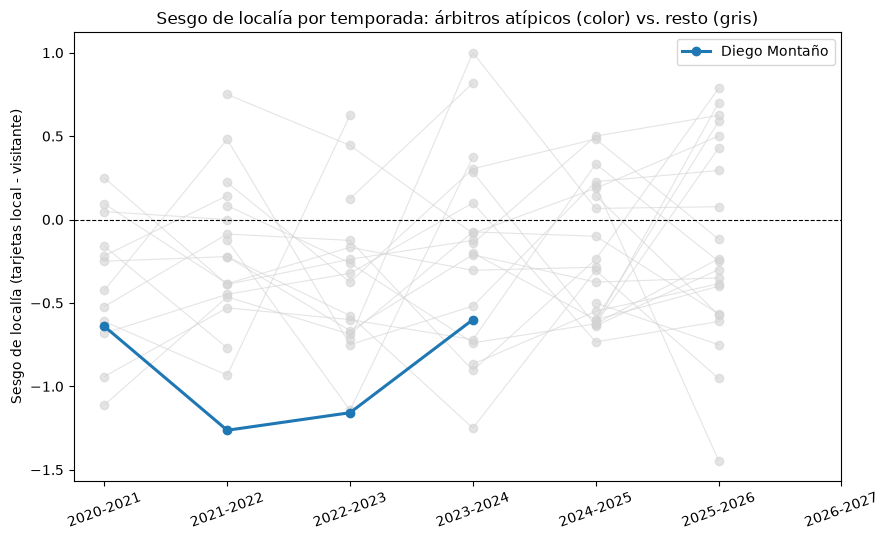

In [22]:
atipicos_actualizados = perfil_arbitro[perfil_arbitro["z_sesgo_localia"].abs() > 2].index.tolist()
print("Árbitros atípicos con nombres consolidados:", atipicos_actualizados)

plt.figure(figsize=(9, 5.5))
for arbitro in calificados:
    datos = serie_arbitro[serie_arbitro["referee"] == arbitro].set_index("season").reindex(temporadas_todas)
    es_atipico = arbitro in atipicos_actualizados
    plt.plot(range(len(temporadas_todas)), datos["sesgo_localia"],
              marker="o", linewidth=2.2 if es_atipico else 0.8,
              color=None if es_atipico else "lightgray",
              alpha=1.0 if es_atipico else 0.6,
              label=arbitro if es_atipico else None, zorder=3 if es_atipico else 1)

plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.xticks(range(len(temporadas_todas)), temporadas_todas, rotation=20)
plt.ylabel("Sesgo de localía (tarjetas local - visitante)")
plt.title("Sesgo de localía por temporada: árbitros atípicos (color) vs. resto (gris)")
plt.legend()
plt.tight_layout()
plt.savefig("/tmp/sesgo_localia_atipicos_vs_resto.png", dpi=150)
plt.show()